In [2]:
!python -m pip install --upgrade pip --default-timeout=300

In [5]:
#$python = "C:\Users\as296\AppData\Local\Programs\Python\Python310\python.exe"

!python -m pip install mlflow --timeout 1200 --retries 10 --no-cache-dir

In [1]:
import mlflow
import pandas as pd
import numpy as np

c:\Users\as296\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("preprocessed_df.csv")

In [6]:
df.columns

Index(['Unnamed: 0', 'clean_comment', 'category'], dtype='object')

In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them th...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [11]:
!pip install nltk

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.2 MB/s  0:00:00
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ---------------

In [4]:
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [5]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\as296\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\as296\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
def preprocess_comment(comment):
    comment = comment.lower()
    comment = comment.strip()

    comment = re.sub(r'\n', ' ', comment)

    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', ' ', comment)

    stop_words = set(stopwords.words("english")) - {"not", "but", "however", "no", "yet"}
    comment = " ".join([word for word in comment.split() if word not in stop_words])

    lemmatizer = WordNetLemmatizer()
    comment = " ".join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [8]:
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

In [18]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [9]:
df['category'].value_counts()

category
 1    15771
 0    12772
-1     8250
Name: count, dtype: int64

In [9]:
df_neg_1 = df[df['category']==-1.0].reset_index()

In [10]:
df_neg_1.drop(columns=['index'], inplace=True)

In [12]:
df_neg_1

,clean_comment,category
0,seriously say thing first get complex explain ...,-1
1,sit together watch simpson episode lisa become...,-1
2,two variety christian dogmatic dwell word cons...,-1
3,evil include lady pai chunked,-1
4,technically could argue sobek evil would repre...,-1
...,...,...
8245,else supposed ask vote violation illegally inf...,-1
8246,modi like trump obsessed criticizing medium na...,-1
8247,fuck nearly want rush atm,-1
8248,seriously india done press conference guy stil...,-1


In [11]:
df_0 = df[df['category']==0.0].reset_index()

In [12]:
df_0.drop(columns=['index'], inplace=True)

In [13]:
df_0 = df_0.sample(n=8250, random_state=42).reset_index()

In [14]:
df_0.drop(columns=['index'], inplace=True)

In [15]:
len(df_0)

8250

In [16]:
df_1 = df[df['category']==1.0].reset_index().drop(columns=['index'])

In [17]:
df_1

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,benefit may want read living buddha living chr...,1
3,teen discovered zen meditation undiagnosed bpd...,1
4,dont worry trying explain meditate regularly t...,1
...,...,...
15766,part series minute video focusing different pa...,1
15767,fan modi but best people ever met life indian ...,1
15768,nice shock laga effect night demonetization,1
15769,kya bhai pure saal chutiya banaya modi aur jab...,1


In [18]:
df_1 = df_1.sample(n=8250, random_state=42).reset_index().drop(columns=['index'])

In [19]:
df_balanced = pd.concat([df_1, df_0, df_neg_1], ignore_index=True)

In [20]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [21]:
df_balanced

,clean_comment,category
0,not indian aadhaar,0
1,india repeatedly approached usa repeatedly ign...,1
2,know india wil give befitting reply attack inn...,1
3,every citizen linked bank account aadhaar get ...,0
4,chaliye vadraji wannakam,0
...,...,...
24745,realised couple year back got conversation fel...,-1
24746,meet new bos old bos,1
24747,people not realise always critical edgy matter...,1
24748,pata hai aap sabko,0


In [22]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [23]:
countvectorizer = CountVectorizer(max_features=10000)

X = countvectorizer.fit_transform(df_balanced['clean_comment']).toarray()
Y = df_balanced['category']

In [24]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(24750, 10000))

In [27]:
Y

0        0
1        1
2        1
3        0
4        0
        ..
24745   -1
24746    1
24747    1
24748    0
24749   -1
Name: category, Length: 24750, dtype: int64

In [25]:
mlflow.set_tracking_uri("http://ec2-43-204-97-155.ap-south-1.compute.amazonaws.com:5000/")

In [26]:
mlflow.set_experiment("RandomForest Baseline")

<Experiment: artifact_location='s3://mlflow-bucket-2181/1', creation_time=1789667842579, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789667842579, lifecycle_stage='active', name='RandomForest Baseline', tags={}, trace_location=None, workspace='default'>

In [58]:
!pip install boto3

  Using cached s3transfer-0.19.2-py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
    --------------------------------------- 0.3/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 1.0 MB/s eta 0:00:15
   - -------------------------------------- 0.8/15.8 MB 1.2 MB/s eta 0:00:13
   -- ------------------------------------- 1.0/15.8 MB 1.1 MB/s eta 0:00:13
   --- ------------------------------------ 1.3/15.8 MB 1.2 MB/s eta 0:00:13
   --- ------------------------------------ 1.6/15.8 MB 1.2 MB/s eta 0:00:12
   ----- ---------------------------------- 2.1/15.8 MB 1.3 MB/s eta 0:00:11
   ----- ---------------------------------- 2.4/15.8 MB 1.4 MB/s eta 0:00:10
   ------ --------------------------------- 2.6/15.8 MB 1.4 MB/s eta 0:00:10
   ------- -------------------------------- 3.1/15.8 MB 1.4 MB/s eta 0:00:09
   -------- -----------------

In [59]:
!pip install awscli

   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/20.2 MB 1.5 MB/s eta 0:00:13
   - -------------------------------------- 0.8/20.2 MB 1.7 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/20.2 MB 1.9 MB/s eta 0:00:10
   --- ------------------------------------ 1.6/20.2 MB 2.0 MB/s eta 0:00:10
   ---- ----------------------------------- 2.1/20.2 MB 1.9 MB/s eta 0:00:10
   ----- ---------------------------------- 2.6/20.2 MB 2.0 MB/s eta 0:00:09
   ------ --------------------------------- 3.1/20.2 MB 2.1 MB/s eta 0:00:09
   ------- -------------------------------- 3.7/20.2 MB 2.2 MB/s eta 0:00:08
   -------- ------------------------------- 4.2/20.2 MB 2.2 MB/s eta 0:00:08
   --------- ------------------------------ 4.7/20.2 MB 2.2 MB/s eta 0:00:08
   ---------- ------

In [ ]:
!aws configure set aws_access_key_id ""
!aws configure set aws_secret_access_key ""
!aws configure set region "ap-south-1"

In [28]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=.2, random_state=42, stratify=Y)

In [67]:
!pip install seaborn

In [29]:
import seaborn as sns

🏃 View run abrasive-mouse-139 at: http://ec2-43-204-97-155.ap-south-1.compute.amazonaws.com:5000/#/experiments/1/runs/b058c5f41d74480292e4ff178563c2cf
🧪 View experiment at: http://ec2-43-204-97-155.ap-south-1.compute.amazonaws.com:5000/#/experiments/1
Accuracy: 0.668080808080808


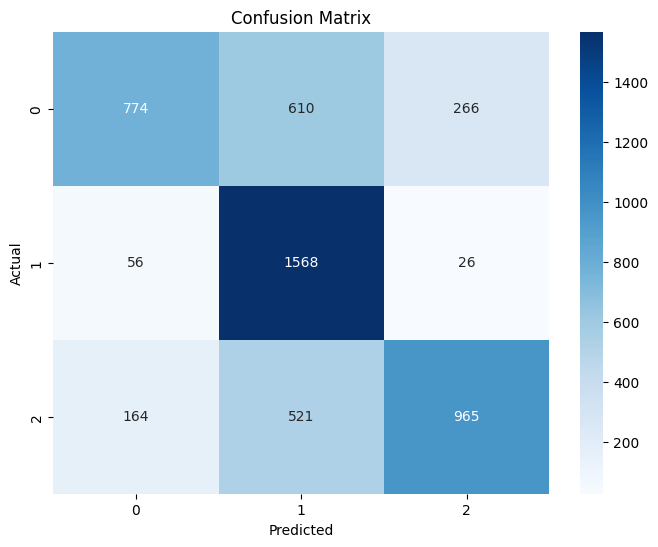

In [32]:
with mlflow.start_run() as run:
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", countvectorizer.max_features)
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    mlflow.sklearn.log_model(
        model,
        name="RandomForest_baseline_model",
        skops_trusted_types=["sklearn.tree._tree.Tree"],
    )

    df_balanced.to_csv("df_balanced.csv")
    mlflow.log_artifact("df_balanced.csv")

print(f"Accuracy: {accuracy}")

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.78      0.47      0.59      1650
           0       0.58      0.95      0.72      1650
           1       0.77      0.58      0.66      1650

    accuracy                           0.67      4950
   macro avg       0.71      0.67      0.66      4950
weighted avg       0.71      0.67      0.66      4950

